<a href="https://colab.research.google.com/github/raphaelassoun23/Projet-Python/blob/main/notebooks/MonteCarloCrypto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
from pathlib import Path

SRC_PATH = Path("..") / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from fetch import fetch_dataset

In [2]:
from config import TICKERS, ROLLING_WINDOW_DAYS, EVENT_DATE, EVENT_WINDOW_DAYS, EVENT_ROLLING_DAYS
from fetch import fetch_dataset
from process import build_final_dataset
from visualize import (
    print_correlations, plot_btc_sp500, plot_btc_nasdaq, plot_sp500_nasdaq, plot_event_window, 
    plot_btc_and_us10y, plot_rolling_corr, plot_scatter_returns, plot_event_study_rate_shocks, 
    plot_btc_vs_slope, plot_asset_and_us10y,plot_rolling_corr_generic,plot_event_study_rate_shocks_multi
)

Les valeurs manquantes présentes dans le dataset proviennent uniquement des transformations réalisées (retours, volatilités, moyennes mobiles). Ces NaN correspondent aux premières observations où les fenêtres de calcul ne sont pas encore complètes.
Ils ne représentent donc pas de véritables trous dans les données.
Leur suppression est justifiée, car elle ne retire qu’un très faible nombre d’observations et évite d’introduire un biais par une imputation artificielle
(par la moyenne,par la médiane ou par régression)

c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\fetch.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max").reset_index()
[*********************100%***********************]  1 of 1 completed
c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\fetch.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max").reset_index()
[*********************100%***********************]  1 of 1 completed
c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\fetch.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max").reset_index()
[*********************100%***********************]  1 of 1 completed
c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\fetch.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticke

                     BTC_return_daily  SP500_return_daily  NASDAQ_return_daily
BTC_return_daily             1.000000            0.294990             0.311706
SP500_return_daily           0.294990            1.000000             0.950932
NASDAQ_return_daily          0.311706            0.950932             1.000000

                     ETH_return_daily  SP500_return_daily  NASDAQ_return_daily
ETH_return_daily             1.000000            0.322073             0.336420
SP500_return_daily           0.322073            1.000000             0.950932
NASDAQ_return_daily          0.336420            0.950932             1.000000

                  ETH_return_daily  BTC_return_daily
ETH_return_daily          1.000000          0.812507
BTC_return_daily          0.812507          1.000000



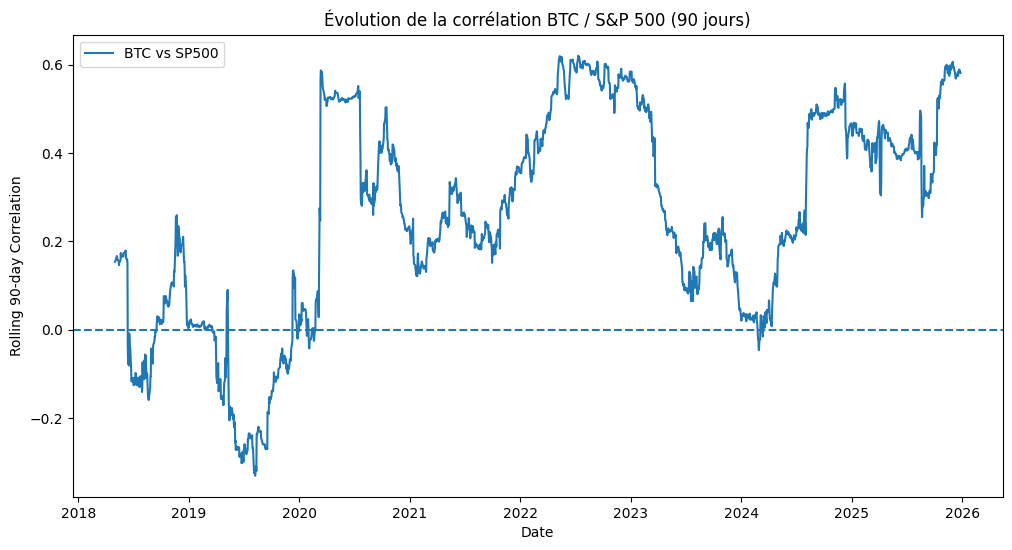

In [3]:
df = fetch_dataset(TICKERS)
df_final = build_final_dataset(df)

print_correlations(df_final)
plot_btc_sp500(df_final)

Les premières observations sur les rendements journaliers montrent que le Bitcoin présente une corrélation faible à modérée avec le S&P 500 (≈0,29) et le NASDAQ (≈0,31). En comparaison, le S&P 500 et le NASDAQ sont fortement corrélés entre eux (≈0,95), comme attendu.
Ces résultats suggèrent qu’au niveau global, le Bitcoin ne suit pas étroitement les marchés financiers traditionnels et pourrait évoluer de manière relativement indépendante. Il s’agit pour l’instant d’une analyse exploratoire, qui devra être complétée par une étude dynamique dans le temps et des tests plus approfondis pour confirmer ces tendances.

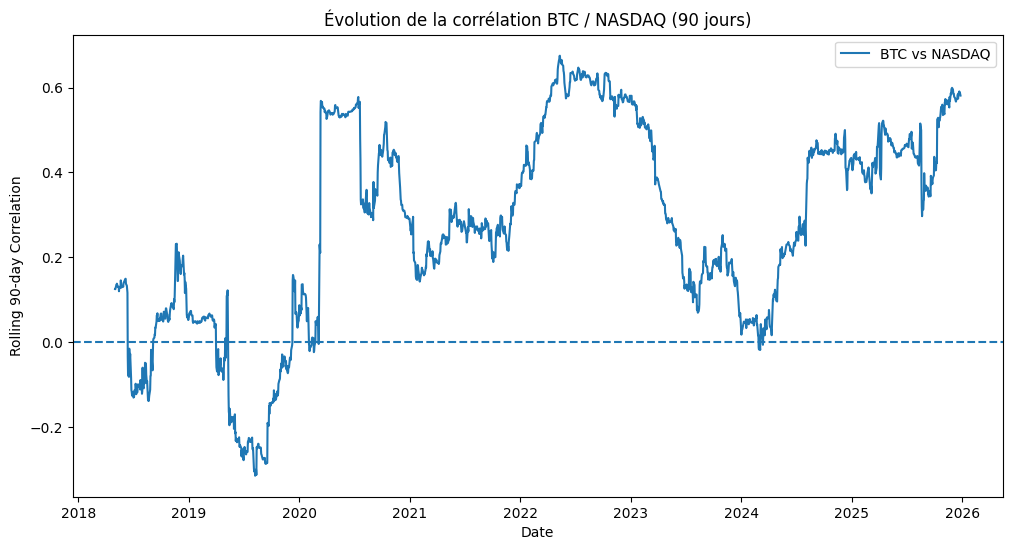

In [4]:
plot_btc_nasdaq(df_final)

Le graphique met en évidence une corrélation très instable dans le temps entre Bitcoin et les indices boursiers traditionnels (Nasdaq et S&P 500). Contrairement aux actifs financiers classiques, dont la corrélation reste généralement plus stable, Bitcoin présente une structure de dépendance très volatile : certaines périodes montrent une corrélation nettement positive, tandis que d’autres phases se caractérisent par une décorrélation quasi totale.
Cette dynamique confirme que Bitcoin ne réagit pas systématiquement aux mêmes facteurs macroéconomiques que les actions. Les phases de corrélation élevée semblent principalement associées à des épisodes de tension macro ou financière, où les actifs risqués évoluent de manière plus synchronisée. À l’inverse, lorsque les conditions se normalisent, Bitcoin retrouve un comportement plus autonome.
Ces résultats suggèrent que Bitcoin ne pourrait pas être considéré comme un actif structurellement aligné avec les marchés actions : son potentiel de diversification dépend fortement de la période étudiée.

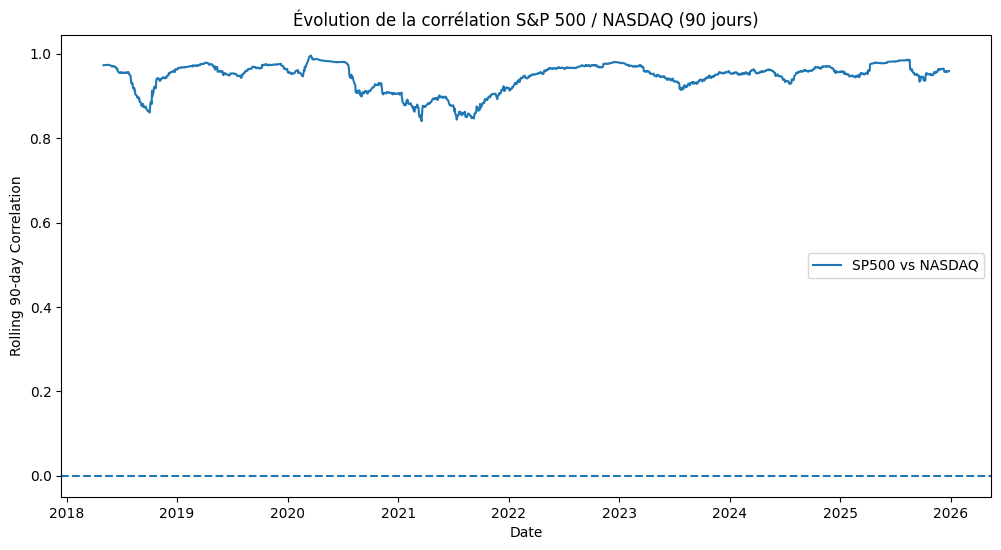

In [5]:
plot_sp500_nasdaq(df_final)

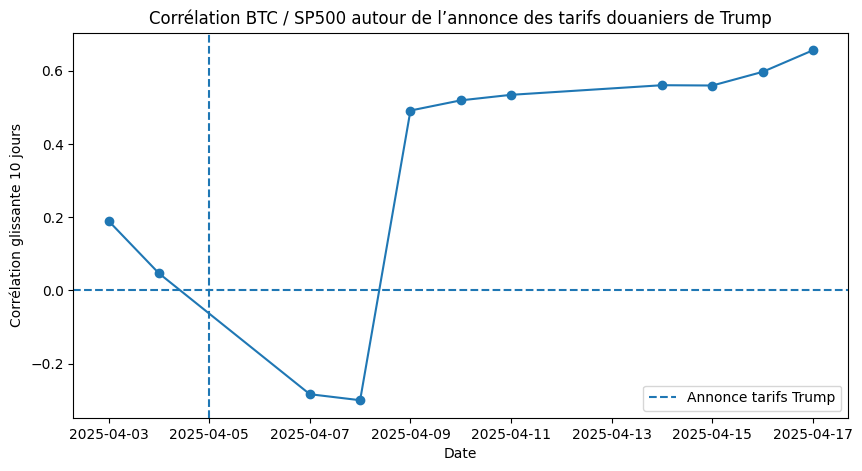

In [6]:
plot_event_window(
    df_final,
    EVENT_DATE,
    window_days=EVENT_WINDOW_DAYS,
    rolling_days=EVENT_ROLLING_DAYS
)

Pendant l’annonce des tarifs douaniers, la corrélation BTC / SP500 augmente, car un choc macroéconomique majeur fait réagir simultanément les investisseurs sur plusieurs actifs. Cette corrélation élevée est temporaire, et Bitcoin reprend ensuite son comportement relativement indépendant comme on a pu le voir avec les graphes précédents.

## III/ Corrélation entre le Bitcoin, le NASDAQ et les taux d'intérêts américains

Cette section analyse la relation entre le Bitcoin et les taux d’intérêt américains à travers le taux des obligations du Trésor à 10 ans (US10Y). L’objectif est d’évaluer dans quelle mesure le Bitcoin est sensible aux conditions macroéconomiques, et en particulier au coût du capital.

## Bitcoin et taux d'intérêt américains

### 1) BTC vs US10Y (prix/niveau du taux)

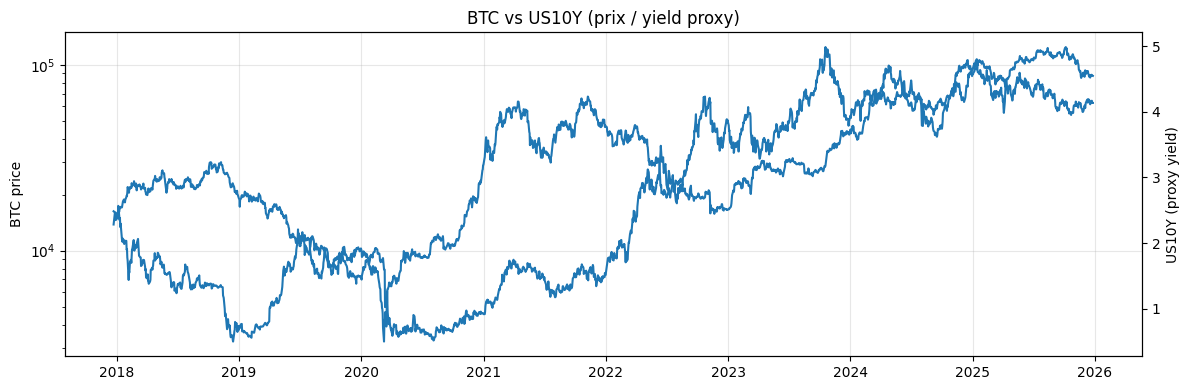

In [7]:
plot_btc_and_us10y(df_final)

La comparaison entre le prix du Bitcoin (en échelle logarithmique) et le niveau du taux US10Y montre qu’il n’existe pas de relation évidente en niveau entre les deux séries.  
Le Bitcoin évolue selon des cycles marqués, tandis que le taux US10Y suit des dynamiques plus lentes, liées aux anticipations de politique monétaire et d’inflation.

Cette absence de relation en niveau justifie l’analyse des variations de court terme du taux (ΔUS10Y) et des rendements du Bitcoin plutôt que des niveaux de prix.

### 2) Corrélation glissante (60 jours) : BTC returns vs ΔUS10Y

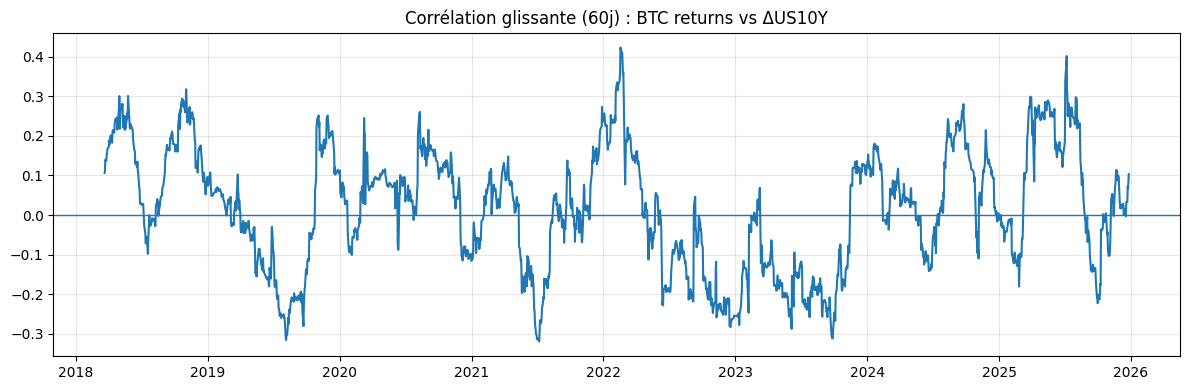

In [8]:
plot_rolling_corr(df_final)

La corrélation glissante sur 60 jours entre les rendements du Bitcoin et les variations quotidiennes du taux US10Y est instable dans le temps.  
Elle alterne entre des phases positives et négatives, avec une valeur moyenne proche de zéro.

Ces résultats suggèrent que la relation entre Bitcoin et taux d’intérêt n’est pas structurelle mais dépend fortement du régime macroéconomique et financier. Le lien entre les deux variables peut se renforcer ou s’inverser selon les périodes.

### 3) Scatter : BTC returns vs ΔUS10Y (par régime de volatilité BTC)

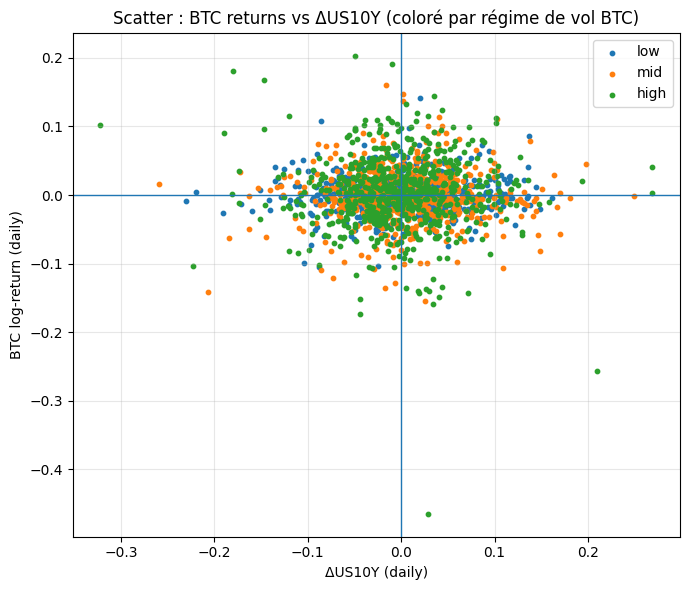

In [9]:
plot_scatter_returns(df_final)

Le nuage de points représentant les rendements du Bitcoin en fonction de ΔUS10Y met en évidence une relation globale faible entre les deux variables.  
Cependant, lorsque la volatilité du Bitcoin est élevée, la dispersion des rendements est nettement plus importante.

Cela indique que les variations de taux n’expliquent pas directement les rendements du Bitcoin, mais qu’elles peuvent amplifier les mouvements du marché lors des périodes de forte instabilité.

### 4) Event study : BTC autour des chocs de taux (|ΔUS10Y| ≥ 99ᵉ percentile)

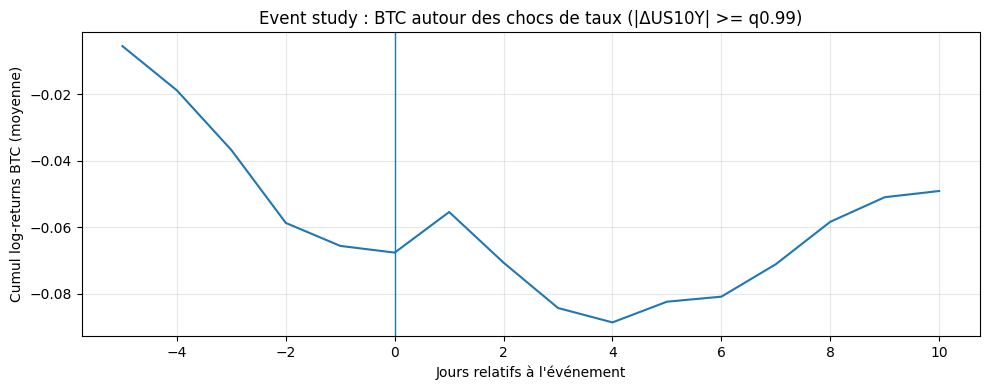

In [10]:
plot_event_study_rate_shocks(df_final, shock_quantile=0.99, pre=5, post=10)

L’event study se concentre sur les jours où les variations du taux US10Y sont extrêmes (au-delà du 99ᵉ percentile).  
On observe que ces chocs de taux sont associés à des rendements cumulés négatifs du Bitcoin dans les jours qui suivent l’événement.

L’impact n’est pas strictement instantané, mais semble persister sur plusieurs jours, suggérant que les chocs de taux constituent des événements macroéconomiques défavorables pour le Bitcoin.


## Actions traditionnelles et taux d'intérêt américains

### 5) US10Y vs NASDAQ/S&P500

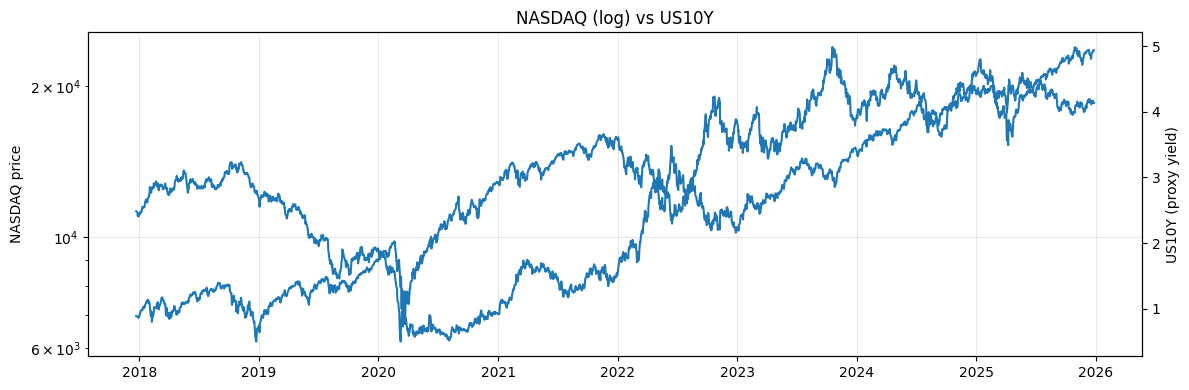

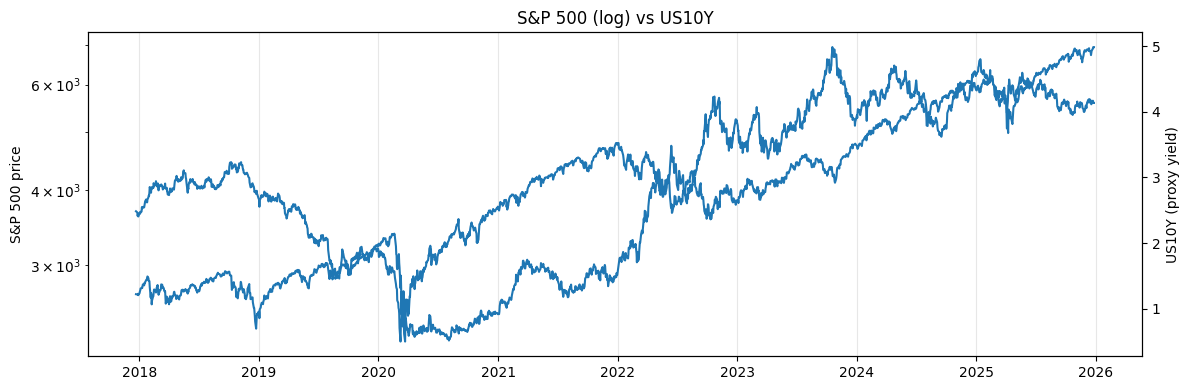

In [11]:
plot_asset_and_us10y(
    df_final,
    asset_price_col="NASDAQ_price",
    asset_label="NASDAQ",
    log_asset=True,
    title="NASDAQ (log) vs US10Y"
)

plot_asset_and_us10y(
    df_final,
    asset_price_col="SP500_price",
    asset_label="S&P 500",
    log_asset=True,
    title="S&P 500 (log) vs US10Y"
)

Les graphiques présentent l’évolution des indices NASDAQ et S&P 500 (en échelle logarithmique) comparée au niveau du taux d’intérêt américain à 10 ans (US10Y). Ils permettent d’examiner la relation entre marchés actions et conditions financières globales.

Dans les deux cas, aucune relation mécanique ne se dégage en niveau entre les indices boursiers et le taux US10Y. Les indices suivent une tendance haussière de long terme, interrompue par des phases de correction marquées (notamment en 2020 et 2022), tandis que le taux US10Y évolue selon des cycles plus lents, liés à la politique monétaire et aux anticipations macroéconomiques.

On observe néanmoins que les phases de hausse rapide des taux, en particulier à partir de 2021–2022, coïncident avec des périodes de stagnation ou de correction des marchés actions. Ce phénomène est particulièrement visible sur le NASDAQ, plus orienté vers les valeurs de croissance, dont la valorisation est théoriquement plus sensible aux variations du taux d’actualisation.

Le S&P 500, plus diversifié sectoriellement, semble réagir de manière plus modérée aux variations du taux US10Y, bien que la dynamique générale reste comparable. Ces observations suggèrent que le taux d’intérêt agit comme un facteur de contexte macroéconomique influençant les marchés actions, sans déterminer à lui seul leur trajectoire.

Ces constats justifient une analyse en rendements et en variations de taux (ΔUS10Y) afin de mieux capturer les interactions de court terme entre taux d’intérêt et marchés actions.


### 6) Corrélations glissantes : actions vs ΔUS10Y

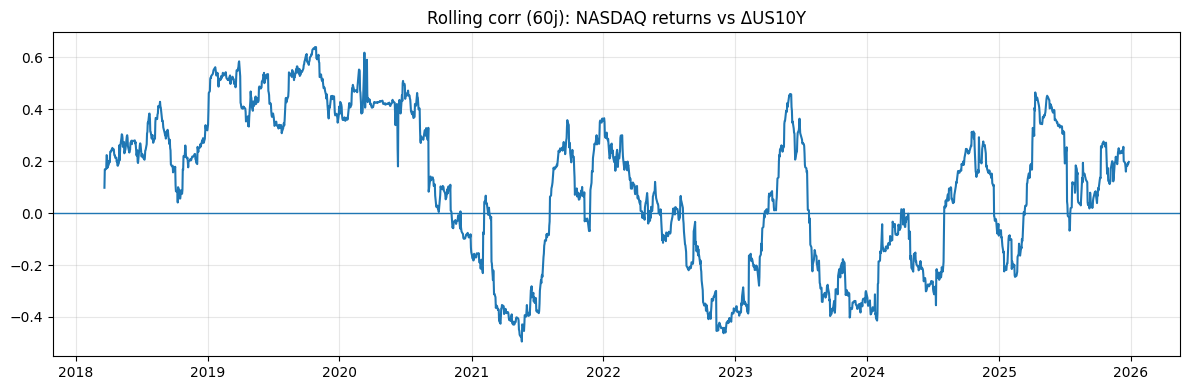

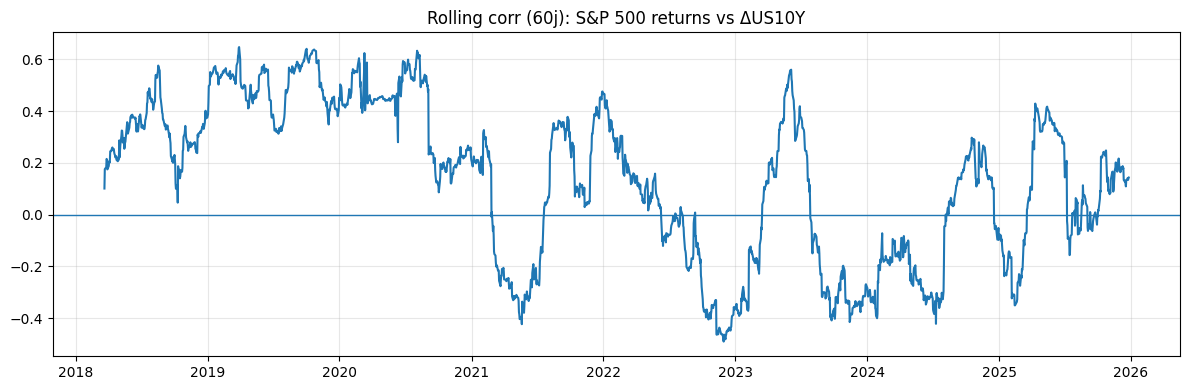

In [12]:
plot_rolling_corr_generic(
    df_final,
    x_col="NASDAQ_return_daily",
    y_col="US10Y_return_daily",
    window=60,
    title="Rolling corr (60j): NASDAQ returns vs ΔUS10Y"
)

plot_rolling_corr_generic(
    df_final,
    x_col="SP500_return_daily",
    y_col="US10Y_return_daily",
    window=60,
    title="Rolling corr (60j): S&P 500 returns vs ΔUS10Y"
)


Les graphiques présentent la corrélation glissante sur 60 jours entre les rendements du NASDAQ et du S&P 500 et les variations quotidiennes du taux d’intérêt américain à 10 ans (ΔUS10Y).

Dans les deux cas, la corrélation est fortement variable dans le temps et alterne entre des phases positives et négatives. Cette instabilité souligne le caractère non structurel de la relation entre marchés actions et taux d’intérêt, qui dépend étroitement du contexte macroéconomique et financier.

On observe des périodes de corrélation positive, notamment avant 2020, où les hausses de taux coïncident avec des performances positives des marchés actions, suggérant un environnement de croissance et d’anticipations macroéconomiques favorables. À l’inverse, des phases de corrélation négative apparaissent lors des épisodes de resserrement monétaire, en particulier autour de 2021–2023, période marquée par des hausses rapides des taux et des corrections boursières.

La dynamique est globalement plus marquée pour le NASDAQ, indice davantage exposé aux valeurs de croissance, tandis que le S&P 500 présente une corrélation légèrement plus modérée, cohérente avec sa composition sectorielle plus diversifiée.

Ces résultats confirment que les variations de taux d’intérêt influencent les marchés actions de manière conditionnelle et non linéaire, ce qui justifie une analyse par régimes et par événements plutôt qu’une corrélation moyenne sur l’ensemble de la période.


### 7) Event study multi-séries (BTC vs NASDAQ) sur les mêmes chocs de taux

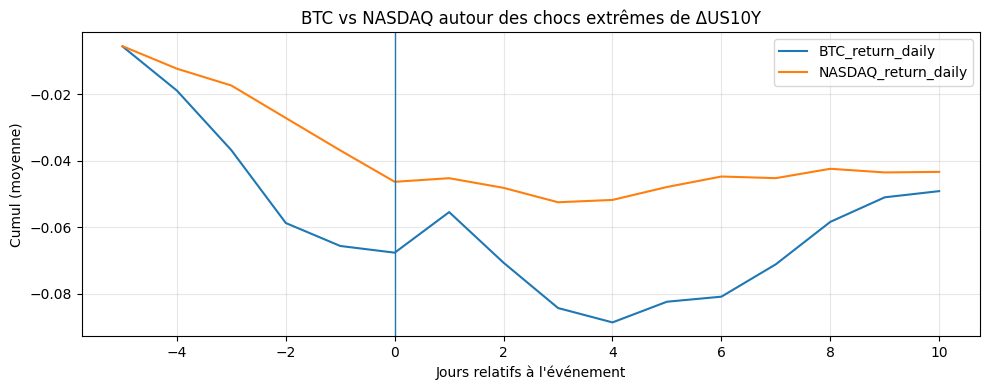

In [13]:
plot_event_study_rate_shocks_multi(
    df_final,
    shock_col="US10Y_return_daily",
    series_cols=["BTC_return_daily", "NASDAQ_return_daily"],
    shock_quantile=0.99,
    pre=5,
    post=10,
    title="BTC vs NASDAQ autour des chocs extrêmes de ΔUS10Y"
)


Ce graphique présente une event study comparant l’évolution moyenne cumulée des rendements du Bitcoin et du NASDAQ autour des jours où les variations du taux d’intérêt américain à 10 ans (ΔUS10Y) sont extrêmes (au-delà du 99ᵉ percentile).

Les deux actifs enregistrent des performances négatives autour des chocs de taux, suggérant que ces événements macroéconomiques constituent des chocs défavorables pour l’ensemble des actifs risqués. Cependant, l’ampleur et la dynamique de la réaction diffèrent sensiblement entre le Bitcoin et le NASDAQ.

Le Bitcoin présente une réaction plus forte et plus persistante, avec une baisse cumulée plus marquée dans les jours suivant l’événement. À l’inverse, le NASDAQ affiche une correction plus modérée et un profil plus stable, avec une récupération progressive après le choc.

Cette divergence suggère que, bien que le Bitcoin partage certaines caractéristiques des actifs risqués traditionnels, il amplifie les chocs macroéconomiques liés aux taux d’intérêt. Le Bitcoin apparaît ainsi comme un actif plus sensible et plus volatil face aux épisodes de stress financier, tandis que les marchés actions absorbent ces chocs de manière plus graduelle.

Ces résultats renforcent l’interprétation du Bitcoin comme un actif intégré au régime « risk-on / risk-off », mais présentant une exposition accrue aux chocs macroéconomiques par rapport aux indices actions traditionnels.


## Conclusion

Dans l’ensemble, l’analyse met en évidence une relation complexe et non linéaire entre le Bitcoin et les taux d’intérêt américains.  
Si aucune corrélation stable n’apparaît en moyenne, les variations de taux jouent un rôle important en période de stress macroéconomique et de forte volatilité du Bitcoin.

L’étude des marchés actions montre que les taux d’intérêt influencent plus directement les indices boursiers américains, en particulier le NASDAQ, dont la valorisation est sensible au taux d’actualisation. Cette relation apparaît plus structurée et plus régulière que celle observée pour le Bitcoin, ce qui suggère que les marchés actions constituent un canal privilégié de transmission des chocs de taux.

La comparaison entre le Bitcoin et les indices actions autour des chocs extrêmes de taux met en évidence une réaction plus ample et plus persistante du Bitcoin. Bien que les deux classes d’actifs subissent des performances négatives lors de ces épisodes, le Bitcoin amplifie les chocs macroéconomiques par rapport aux marchés actions traditionnels.

Ces résultats suggèrent que le Bitcoin s’inscrit dans le régime « risk-on / risk-off » des marchés financiers, tout en présentant une sensibilité accrue aux conditions financières globales. Il se comporte ainsi davantage comme un actif risqué fortement exposé aux chocs macroéconomiques que comme un actif véritablement décorrélé des marchés financiers traditionnels.